In [ ]:
import os
import warnings
import logging

os.environ["PYTHONWARNINGS"] = "ignore"

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("py.warnings").setLevel(logging.ERROR)

In [ ]:
!pip install spacy gensim wordcloud pyLDAvis unidecode -q
!python -m spacy download pt_core_news_lg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 687.5 kB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

In [ ]:
url = "https://www.jb.com.br/mundo/2026/05/1059737-papa-alerta-para-riscos-da-ia-nova-forma-de-escravidao-e-da-guerra-em-primeira-enciclica.html"

headers= {
    "User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                   "AppleWebKit/537.36 (KHTML, like Gecko) "
                   "Chrome/114.0.0.0 Safari/537.36")
}


def parse_jb_article(url, headers=headers):

    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    title_tag = soup.select_one("section h1")
    title = title_tag.get_text(" ", strip=True) if title_tag else None

    author_tag = soup.select_one("section h3")
    author = author_tag.get_text(" ", strip=True) if author_tag else None
    author = author[4:].strip()  if author else None
    text_tag_list = soup.select("section p.texto")
    text = ' '.join([
         text_tag.get_text(" ", strip=True) if text_tag else None
         for text_tag in text_tag_list
    ])
    return {
        'url': url,
        'title': title,
        'author': author,
        'body': text
    }

parse_jb_article(url)



{'url': 'https://www.jb.com.br/mundo/2026/05/1059737-papa-alerta-para-riscos-da-ia-nova-forma-de-escravidao-e-da-guerra-em-primeira-enciclica.html',
 'title': "Papa alerta para riscos da IA ('Nova forma de escravidÃ£o') e da guerra em primeira encÃ\xadclica",
 'author': 'JB INTERNACIONAL [email\xa0protected]',
 'body': 'O papa Leão XIV lançou nesta segunda-feira (25) a primeira encíclica de seu pontificado, na qual faz um amplo alerta sobre os riscos éticos da inteligência artificial, o avanço das guerras e a concentração de poder tecnológico nas mãos de poucos grupos econômicos. Com mais de 200 páginas, o documento "Magnifica Humanitas" é dividido em cinco páginas e se inicia com uma reflexão sobre o futuro da humanidade: "A magnífica humanidade criada por Deus enfrenta hoje uma escolha decisiva: erguer uma nova \'Torre de Babel\' ou construir a cidade onde Deus e a humanidade habitam juntos". Ao longo do texto, o pontífice afirma que justiça e fraternidade ainda são possíveis, mas al

In [ ]:
import spacy
from spacy import displacy

nlp = spacy.load("pt_core_news_lg")

In [ ]:
text = parse_jb_article(url)['body'][100:]

doc = nlp(text)

displacy.render(
    doc,
    style="ent",
    jupyter=True
)

In [ ]:
for ent in doc.ents:
    print(ent.text, ent.label_)

Magnifica Humanitas MISC
Deus PER
Torre de Babel LOC
Deus PER
Leão XIV PER
Papa PER
Leão XIV PER
Papa PER
Igreja ORG
Igreja ORG
Igreja Católica ORG
Leão XIV PER
Estados LOC
O Senhor dos Anéis MISC
John Ronald Reuel Tolkien PER
Gandalf PER
Santo Agostinho PER
São Tomás de Aquino PER
Platão PER
Papas MISC
Leão XIII PER
Rerum Novarum MISC
Robert Prevost PER
Pio XI PER
Pio XII PER
João XXIII PER
Paulo VI PER
João Paulo II PER
Bento XVI PER
Francisco PER
Martin Luther King PER
Nelson Mandela PER
Santa Laura Montoya PER
Santa Teresa de Calcutá PER
Dorothy Day PER
Maria Curie PER
Maria Montessori PER
Elisabeth Elliot PER
Wangari Maathai PER
Benziñez Bhutto PER
Maximiliano Kolbe PER
Oscar Romero PER
Enrique Angelelli PER
François-Xavier Nguyen Van Thuan PER
Carta das Nações Unidas ORG
Concílio Vaticano II MISC
Papa PER
Compêndio da Doutrina Social da Igreja MISC
Ansa ORG


In [ ]:
url_base = "https://www.jb.com.br/search/IA/page"
N_PAGES = 20

def get_links(url, headers=headers):

    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")
    a_tag_list = soup.select("div.box-ult-not-pag-rio a")
    return [
        a_tag.get("href") if a_tag else None
        for a_tag in a_tag_list
    ]

links = []
for page in range(1, N_PAGES + 1):
    url = f"{url_base}/{page}/"
    links.extend(get_links(url))

links = set(links)
print(f"Links: {len(links)} found")

Links: 173 found


In [ ]:
from tqdm.auto import tqdm
import pandas as pd
import time

def links_generator(links):
    for link in links:
        yield link
        time.sleep(.6)

df = pd.DataFrame([
    parse_jb_article(link)
    for link in tqdm(links_generator(links),
                     total=len(links),
                     desc=" notícias baixadas")
])

df.head()

 notícias baixadas:   0%|          | 0/173 [00:00<?, ?it/s]

,url,title,author,body
0,https://www.jb.com.br/pais/noticias/2010/06/18...,None,None,
1,https://www.jb.com.br/pais/noticias/2012/07/31...,None,None,
2,https://www.jb.com.br/rio/noticias/2010/10/30/...,None,None,
3,https://www.jb.com.br/brasil/politica/2024/08/...,MP do Rio vai usar IA para analisar registros ...,JORNAL DO BRASIL [email protected],"""Essa ferramenta pretende, a partir de dados q..."
4,https://www.jb.com.br/internacional/2019/04/99...,None,None,


In [ ]:
df = df[df.body.str.strip() != ""]

df.reset_index(drop=True, inplace=True)
df

,url,title,author,body
0,https://www.jb.com.br/brasil/politica/2024/08/...,MP do Rio vai usar IA para analisar registros ...,JORNAL DO BRASIL [email protected],"""Essa ferramenta pretende, a partir de dados q..."
1,https://www.jb.com.br/brasil/justica/2025/06/1...,MinistÃ©rio da JustiÃ§a regulamenta uso de IA ...,JB JURÃDICO [email protected],. Por Alex Rodrigues - O Ministério da Justiça...
2,https://www.jb.com.br/colunistas/o-outro-lado-...,O Outro Lado da Moeda,il protected],. O dado do IBC-Br do Banco Central em feverei...
3,https://www.jb.com.br/colunistas/iesa-rodrigue...,Moda e Estilo,s Ines Rozario,O Morar Mais chega à vigésima edição e Ligia S...
4,https://www.jb.com.br/brasil/2024/10/1052626-b...,B20 discute regulaÃ§Ã£o da IA e empresas de te...,JORNAL DO BRASIL [email protected],Por Bruno Bocchini - O B20 Summit – um dos eve...
5,https://www.jb.com.br/mundo/2025/07/1056220-fo...,FÃ³rum de MÃ­dia do Brics discute cooperaÃ§Ã£o...,JB INTERNACIONAL [email protected],"Cerca de 250 pessoas entre jornalistas, pesqui..."
6,https://www.jb.com.br/ciencia-e-tecnologia/tec...,A IA generativa inaugura um novo capÃ­tulo na ...,DIEGO TEIXEIRA,A IA generativa inaugura um novo capítulo na h...
7,https://www.jb.com.br/ciencia-e-tecnologia/202...,EUA jÃ¡ perderam batalha na esfera da inteligÃ...,JORNAL DO BRASIL [email protected],"É provável que, no espaço de uma década, a Chi..."
8,https://www.jb.com.br/mundo/2023/06/1044341-re...,RegulaÃ§Ã£o contra inteligÃªncia artificial av...,JB INTERNACIONAL [email protected],O Parlamento da União Europeia aprovou nesta q...
9,https://www.jb.com.br/mundo/2025/01/1053991-pa...,Papa envia mensagem a Davos e pede IA voltada ...,JB INTERNACIONAL [email protected],O papa Francisco enviou nesta quinta-feira (23...


In [ ]:
import gensim
import re

from gensim import corpora
from unidecode import unidecode


stopwords_extra = {
    "sobre", "após", "ainda", "também", "segundo", "porque",
    "onde", "quando", "durante", "contra", "desde", "até",
    "ser", "ter", "fazer", "dizer", "ir", "poder", "dever",
    "ano", "dia", "vez", "caso", "parte", "momento",
    # específicas do contexto
    "ia", "tecnologia", "inteligencia", "artificial"
}

stopwords = nlp.Defaults.stop_words.union(stopwords_extra)


In [ ]:
def custom_tokenizer(text):
    text = text.lower()
    text = unidecode(text)
    text = re.sub("http\S+|www\S+", " ", text)
    text = re.sub("[^a-zA-Z0-9À-ÿ\s]", " ", text)
    text = re.sub(r"\s+", " ", text)

    doc = nlp(text)
    tokens = [
        token.lemma_.strip() for token in doc
        if (
            not token.is_stop and
            len(token.lemma_) > 3 and
            not token.lemma_ in stopwords and
            not token.is_digit and
            not token.is_punct
        )
    ]

    return tokens


In [ ]:
num_topics = 5

lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=20,
    iterations=1000,
    alpha="auto",
    eta="auto",
    per_word_topics=True
)

In [ ]:
df['token'] = df.body.apply(custom_tokenizer)

df.head()

,url,title,author,body,token
0,https://www.jb.com.br/brasil/politica/2024/08/...,MP do Rio vai usar IA para analisar registros ...,JORNAL DO BRASIL [email protected],"""Essa ferramenta pretende, a partir de dados q...","[ferramenta, pretender, dado, inserir, orgao, ..."
1,https://www.jb.com.br/brasil/justica/2025/06/1...,MinistÃ©rio da JustiÃ§a regulamenta uso de IA ...,JB JURÃDICO [email protected],. Por Alex Rodrigues - O Ministério da Justiça...,"[Alex, Rodrigues, ministerio, justica, seguran..."
2,https://www.jb.com.br/colunistas/o-outro-lado-...,O Outro Lado da Moeda,il protected],. O dado do IBC-Br do Banco Central em feverei...,"[dado, Banco, central, fevereiro, crescimento,..."
3,https://www.jb.com.br/colunistas/iesa-rodrigue...,Moda e Estilo,s Ines Rozario,O Morar Mais chega à vigésima edição e Ligia S...,"[morar, chegar, vigesimo, edicao, ligia, Schub..."
4,https://www.jb.com.br/brasil/2024/10/1052626-b...,B20 discute regulaÃ§Ã£o da IA e empresas de te...,JORNAL DO BRASIL [email protected],Por Bruno Bocchini - O B20 Summit – um dos eve...,"[Bruno, bocchini, summit, evento, preparatorio..."


In [ ]:
dictionary = corpora.Dictionary(df.token)

dictionary.filter_extremes(
    no_below=3,
    no_above=0.80,
    keep_n=1000
)

corpus = [dictionary.doc2bow(text) for text in df.token]



In [ ]:
for topic_id, topic_words in lda_model.print_topics(num_topics=num_topics, num_words=10):
    print(f"Tópico {topic_id + 1}: {topic_words}")

Tópico 1: 0.030*"imagem" + 0.014*"eleitoral" + 0.012*"governo" + 0.011*"candidato" + 0.010*"publicacao" + 0.009*"justica" + 0.009*"apresentar" + 0.009*"criar" + 0.008*"produzir" + 0.007*"explicar"
Tópico 2: 0.023*"dado" + 0.015*"modelo" + 0.011*"usuario" + 0.009*"cliente" + 0.008*"servico" + 0.008*"plataforma" + 0.008*"ativo" + 0.007*"aumentar" + 0.007*"gerar" + 0.007*"permitir"
Tópico 3: 0.009*"empresa" + 0.009*"feira" + 0.009*"tambem" + 0.008*"sera" + 0.007*"bilhoe" + 0.007*"governanca" + 0.007*"data" + 0.007*"afirmar" + 0.006*"projeto" + 0.006*"digital"
Tópico 4: 0.015*"Brasil" + 0.010*"pessoa" + 0.009*"tambem" + 0.008*"defesa" + 0.007*"seguranca" + 0.007*"brasileiro" + 0.007*"desenvolvimento" + 0.007*"empresa" + 0.006*"presidente" + 0.006*"mundo"
Tópico 5: 0.016*"tambem" + 0.016*"conteudo" + 0.015*"voce" + 0.015*"imagem" + 0.012*"pessoa" + 0.009*"gente" + 0.009*"gerar" + 0.008*"Brasil" + 0.008*"criar" + 0.007*"empresa"


In [ ]:
for topic_id in range(5):
    print("Topic", topic_id, ":", ", ".join([t[0] for t in lda_model.show_topic(topic_id, topn=5)]))

Topic 0 : imagem, eleitoral, governo, candidato, publicacao
Topic 1 : dado, modelo, usuario, cliente, servico
Topic 2 : empresa, feira, tambem, sera, bilhoe
Topic 3 : Brasil, pessoa, tambem, defesa, seguranca
Topic 4 : tambem, conteudo, voce, imagem, pessoa


In [ ]:
#import pyLDAvis
#import pyLDAvis.gensim_models as gensimvis

#pyLDAvis.enable_notebook()
#lda_vis = gensimvis.prepare(
#    lda_model,
#    corpus,
#    dictionary,
#    sort_topics=False
#)

#lda_vis



In [ ]:
!pip install wordcloud -q

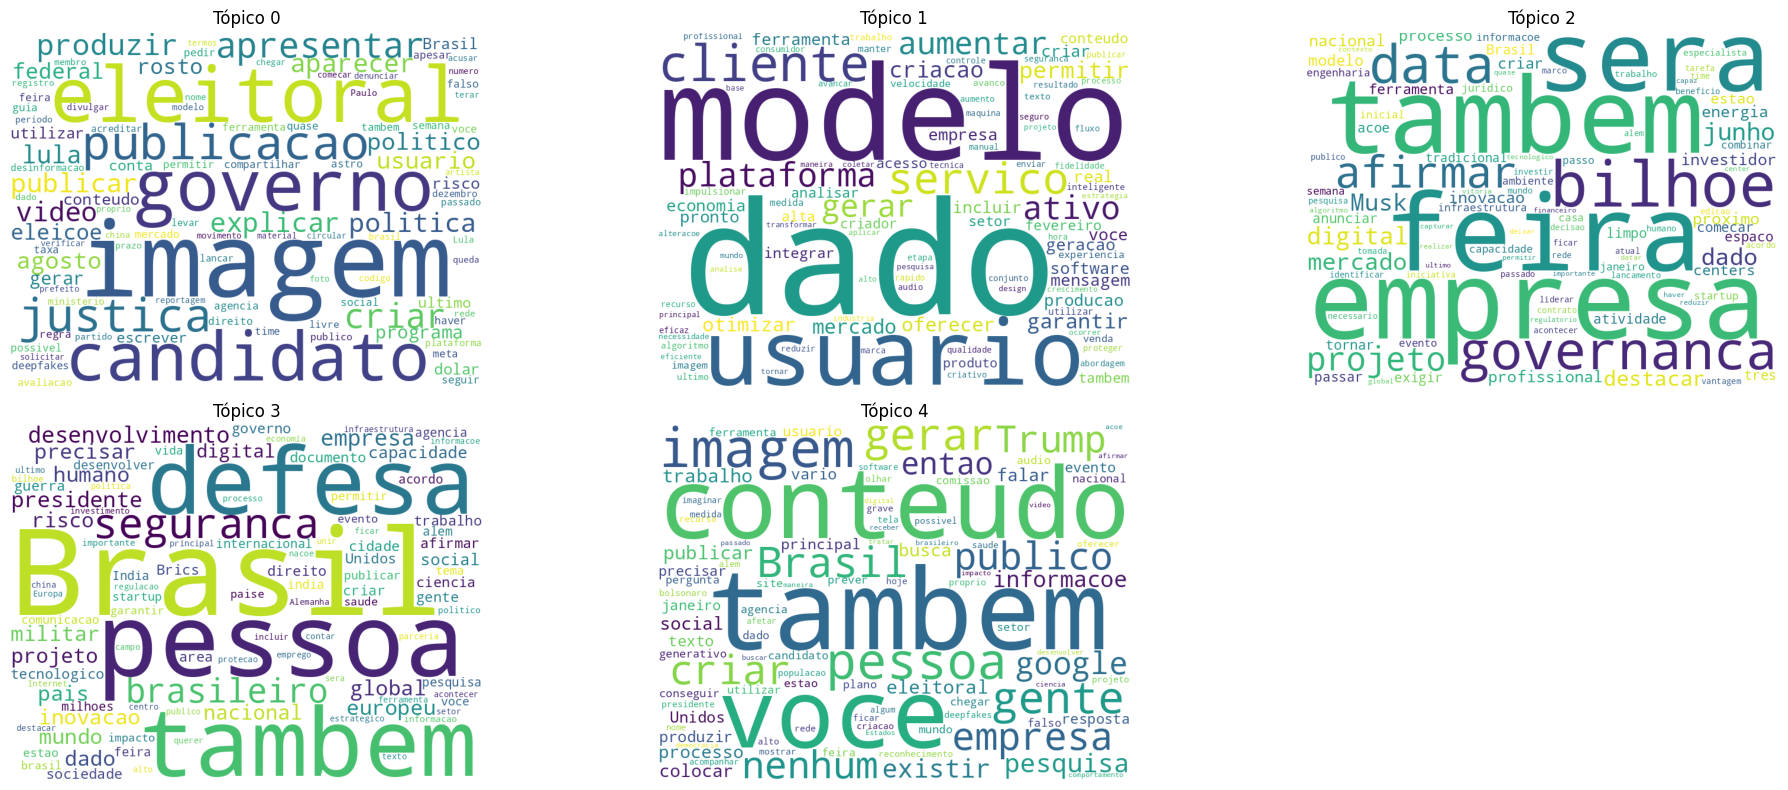

In [ ]:
from wordcloud import WordCloud

import matplotlib.pyplot as plt

def plot_wordcloud(topic_id, ax=None):
    topic_words = lda_model.show_topic(topic_id, topn=100)
    topic_words_dict = {word: freq for word, freq in topic_words}
    wc = WordCloud(
        background_color="white",
        width=800,
        height=600,
        collocations=False,
        prefer_horizontal=1
    )
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(wc.generate_from_frequencies(topic_words_dict))
    ax.axis("off")
    wc.generate_from_frequencies(topic_words_dict)
    return ax

fig, axes = plt.subplots(2, 3, figsize=(20, 8))
for idx, ax in enumerate(axes.flatten()):
    try:
        ax = plot_wordcloud(idx, ax)
        ax.set_title(f"Tópico {idx}")
    except:
        axes.flatten()[idx].remove()

plt.tight_layout()
plt.show()

In [ ]:
def get_topic(bow):
    topic_probs = lda_model.get_document_topics(bow)
    return list(sorted(topic_probs, key=lambda x: x[1]))[0]



In [ ]:
df['topic'] = [get_topic(bow)[0] for bow in corpus]
df['topic_store'] = [get_topic(bow)[1] for bow in corpus]

df.head()

,url,title,author,body,token,topic,topic_store
0,https://www.jb.com.br/brasil/politica/2024/08/...,MP do Rio vai usar IA para analisar registros ...,JORNAL DO BRASIL [email protected],"""Essa ferramenta pretende, a partir de dados q...","[ferramenta, pretender, dado, inserir, orgao, ...",0,0.998757
1,https://www.jb.com.br/brasil/justica/2025/06/1...,MinistÃ©rio da JustiÃ§a regulamenta uso de IA ...,JB JURÃDICO [email protected],. Por Alex Rodrigues - O Ministério da Justiça...,"[Alex, Rodrigues, ministerio, justica, seguran...",3,0.999608
2,https://www.jb.com.br/colunistas/o-outro-lado-...,O Outro Lado da Moeda,il protected],. O dado do IBC-Br do Banco Central em feverei...,"[dado, Banco, central, fevereiro, crescimento,...",1,0.999454
3,https://www.jb.com.br/colunistas/iesa-rodrigue...,Moda e Estilo,s Ines Rozario,O Morar Mais chega à vigésima edição e Ligia S...,"[morar, chegar, vigesimo, edicao, ligia, Schub...",2,0.998996
4,https://www.jb.com.br/brasil/2024/10/1052626-b...,B20 discute regulaÃ§Ã£o da IA e empresas de te...,JORNAL DO BRASIL [email protected],Por Bruno Bocchini - O B20 Summit – um dos eve...,"[Bruno, bocchini, summit, evento, preparatorio...",3,0.999520


In [ ]:
get_topic(corpus[10])

(3, np.float32(0.32005987))

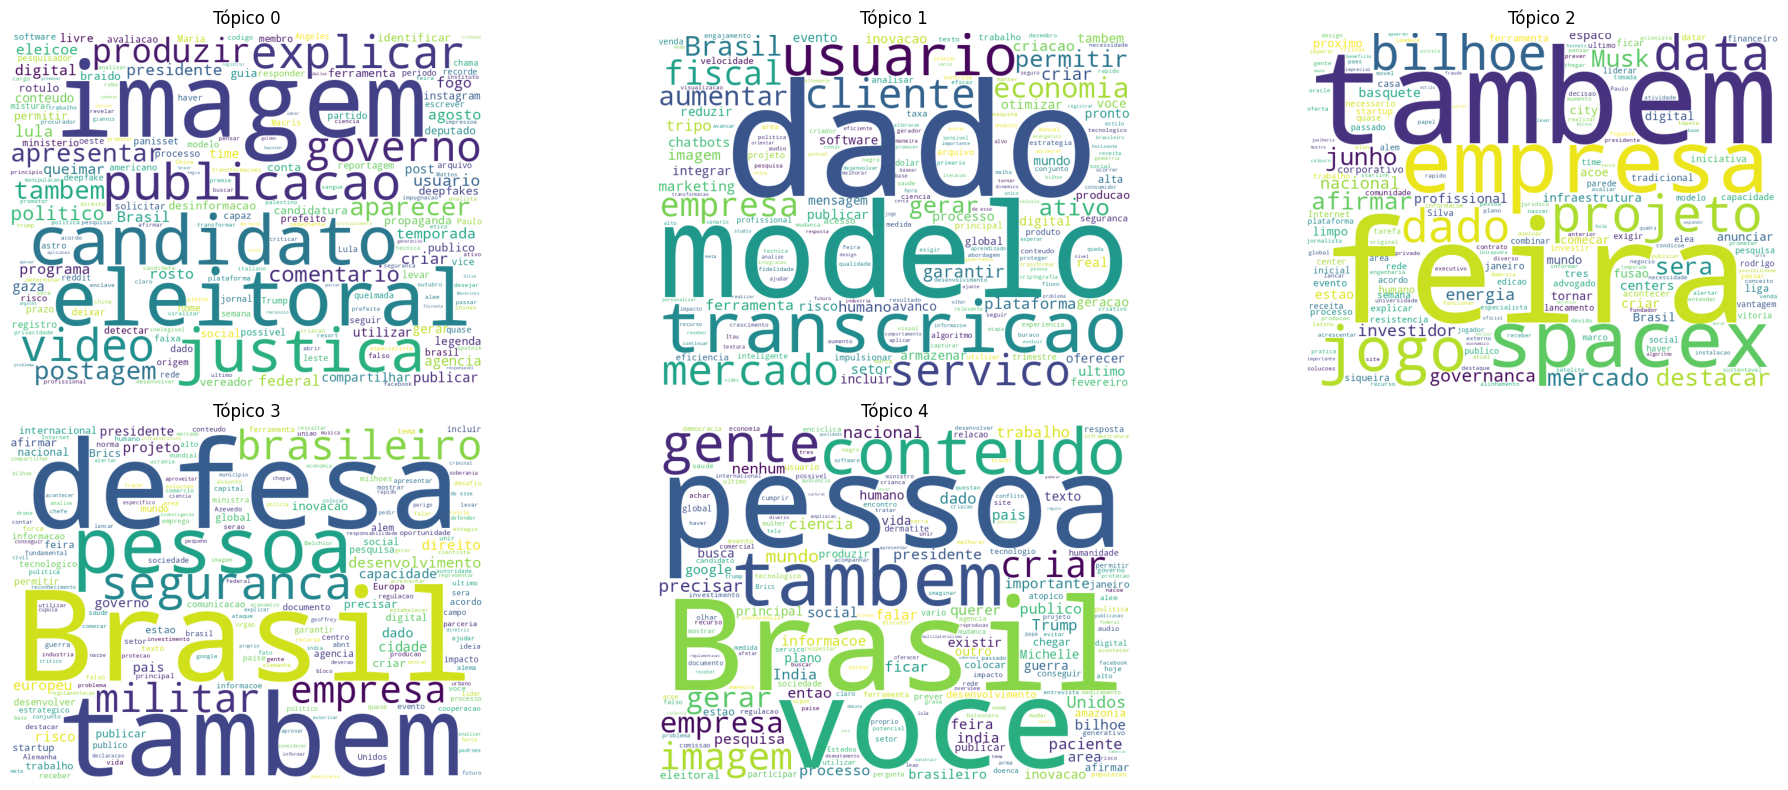

In [ ]:
def plot_wordcloud_word_freq(topic_id, ax=None):
    tokens = df.token[df.topic == topic_id]
    topic_words_dict = {}
    for token in tokens:
        for word in token:
            if word in topic_words_dict:
                topic_words_dict[word] += 1
            else:
                topic_words_dict[word] = 1
    wc = WordCloud(
        background_color="white",
        width=800,
        height=600,
        collocations=False,
        prefer_horizontal=1
    )
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(wc.generate_from_frequencies(topic_words_dict))
    ax.axis("off")
    wc.generate_from_frequencies(topic_words_dict)
    return ax

fig, axes = plt.subplots(2, 3, figsize=(20, 8))
for idx, ax in enumerate(axes.flatten()):
    try:
        ax = plot_wordcloud_word_freq(idx, ax)
        ax.set_title(f"Tópico {idx}")
    except:
        axes.flatten()[idx].remove()

plt.tight_layout()
plt.show()